     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.9 MB/s eta 0:00:00
(2156270, 11)
<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 306316 to 1598764
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            100000 non-null  int64  
 1   type            100000 non-null  object 
 2   amount          100000 non-null  float64
 3   nameOrig        100000 non-null  object 
 4   oldbalanceOrg   100000 non-null  float64
 5   newbalanceOrig  100000 non-null  float64
 6   nameDest        100000 non-null  object 
 7   oldbalanceDest  100000 non-null  float64
 8   newbalanceDest  100000 non-null  float64
 9   isFraud         100000 non-null  float64
 10  isFlaggedFraud  100000 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 9.2+ MB
None
step              0
type              0
amount      

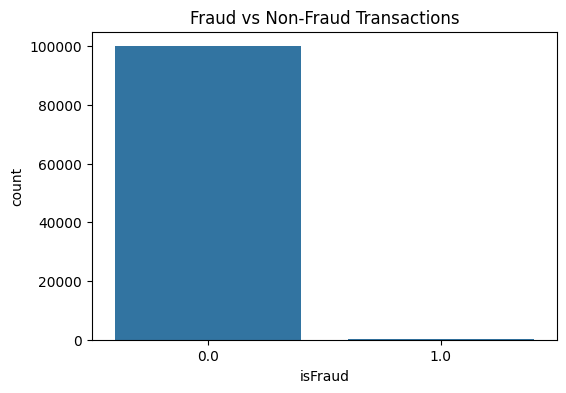

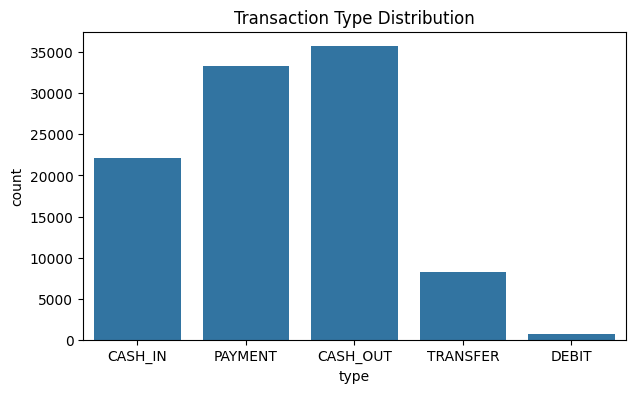

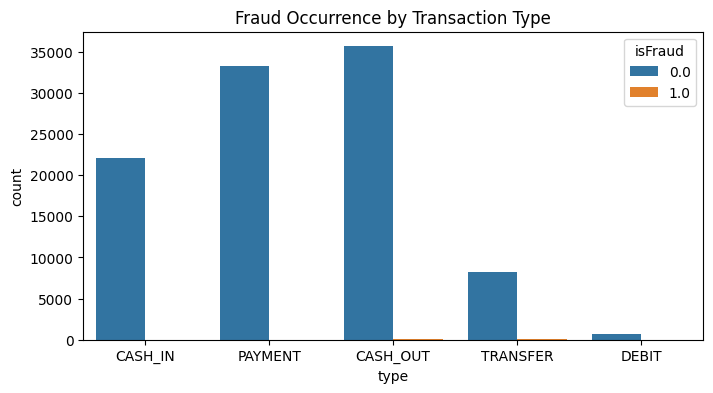

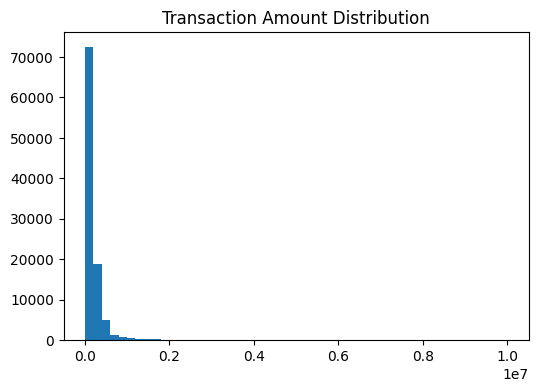

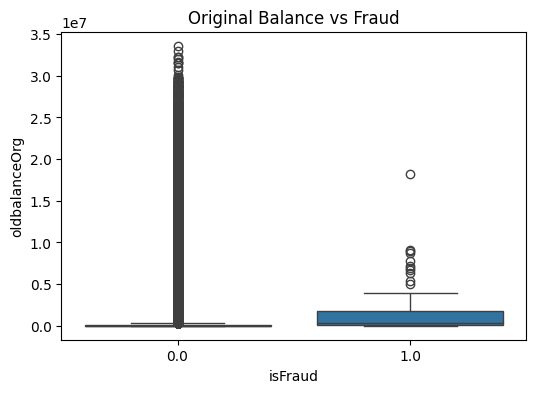

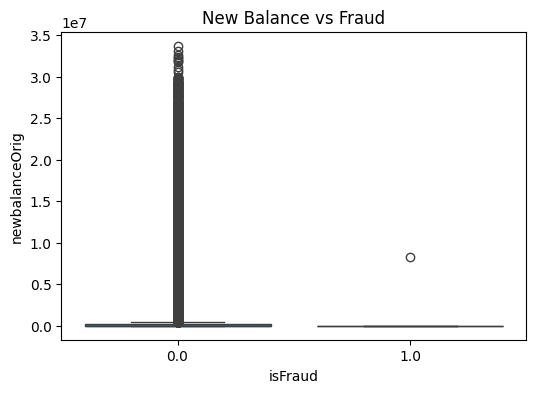

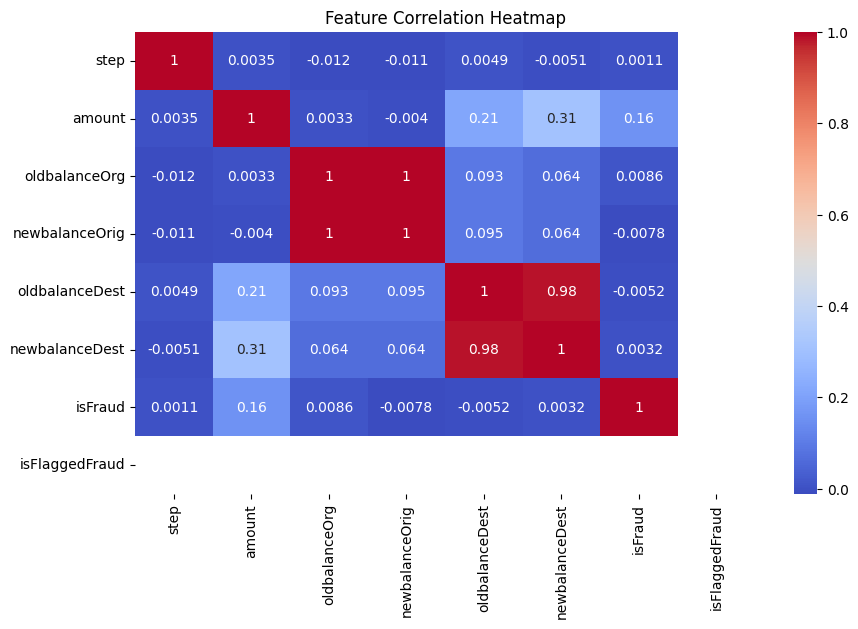


 Logistic Regression
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     19983
         1.0       0.04      0.94      0.07        17

    accuracy                           0.98     20000
   macro avg       0.52      0.96      0.53     20000
weighted avg       1.00      0.98      0.99     20000


 Random Forest
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     19983
         1.0       0.55      0.65      0.59        17

    accuracy                           1.00     20000
   macro avg       0.77      0.82      0.80     20000
weighted avg       1.00      1.00      1.00     20000


 XGBoost
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     19983
         1.0       0.41      0.76      0.53        17

    accuracy                           1.00     20000
   macro avg       0.70      0.88      0.77     20000
weighted avg       1.00   

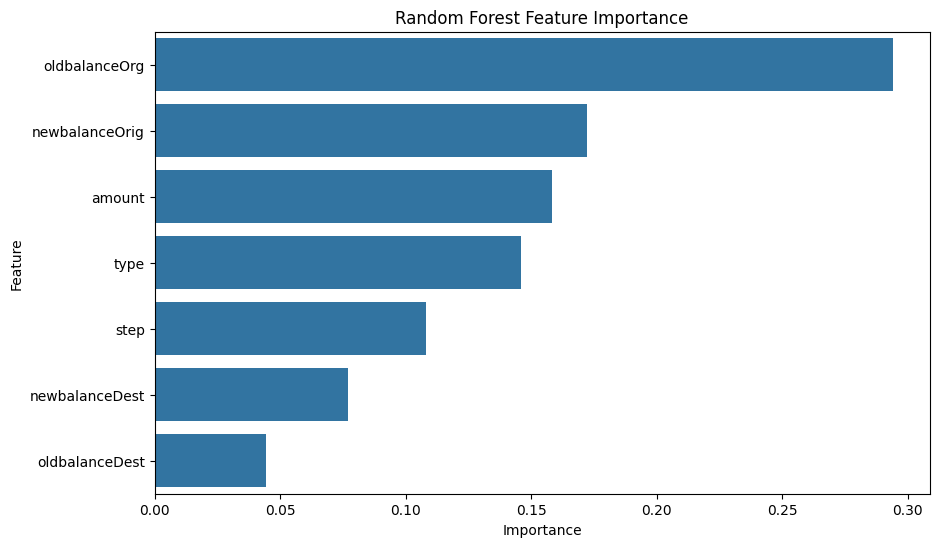

GCN PERFORMANCE on Test Set
Accuracy : 0.9903
Precision: 0.0417
Recall   : 0.3
F1 Score : 0.0732

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      7832
           1       0.04      0.30      0.07        10

    accuracy                           0.99      7842
   macro avg       0.52      0.65      0.53      7842
weighted avg       1.00      0.99      0.99      7842


Confusion Matrix
[[7763   69]
 [   7    3]]


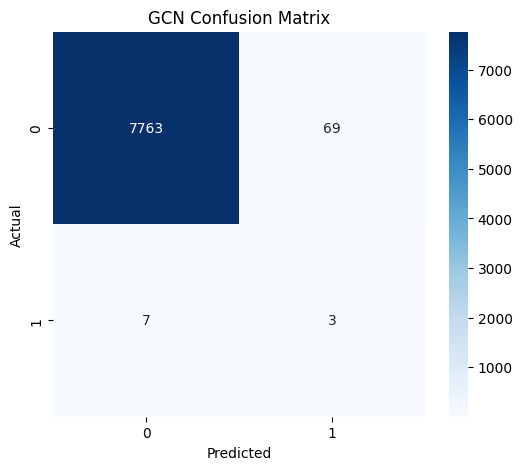

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.979450   0.037559  0.941176  0.072235
1        Random Forest  0.999250   0.550000  0.647059  0.594595
2              XGBoost  0.998850   0.406250  0.764706  0.530612
3                  GCN  0.990309   0.041667  0.300000  0.073171


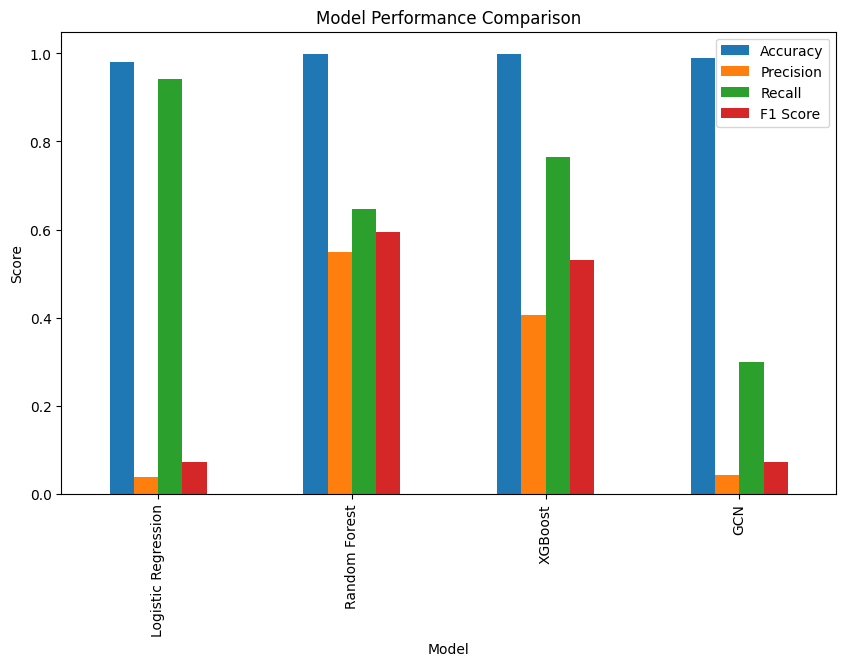

In [1]:
!pip install -q imbalanced-learn xgboost torch-geometric networkx
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx

import torch
import torch.nn.functional as F

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

#LOAD DATA
df = pd.read_csv("/content/Fraud.csv")
print(df.shape)
df.head()
df = df.sample(
    n=100000,
    random_state=42
)

# EDA
print(df.info())

print(df.isnull().sum())

print(df['isFraud'].value_counts())

#FRAUD DISTRIBUTION

plt.figure(figsize=(6,4))

sns.countplot(
    x='isFraud',
    data=df
)

plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

#TRANSACTION TYPE

plt.figure(figsize=(7,4))

sns.countplot(
    x='type',
    data=df
)

plt.title("Transaction Type Distribution")

plt.show()

#FRAUD BY TRANSACTION TYPE

plt.figure(figsize=(8,4))

sns.countplot(
    x='type',
    hue='isFraud',
    data=df
)

plt.title("Fraud Occurrence by Transaction Type")

plt.show()

#AMOUNT DISTRIBUTION

plt.figure(figsize=(6,4))

plt.hist(
    df['amount'],
    bins=50
)

plt.title("Transaction Amount Distribution")

plt.show()

#BOXPLOTS

plt.figure(figsize=(6,4))
sns.boxplot(
    x='isFraud',
    y='oldbalanceOrg',
    data=df
)
plt.title("Original Balance vs Fraud")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(
    x='isFraud',
    y='newbalanceOrig',
    data=df
)
plt.title("New Balance vs Fraud")
plt.show()

#HEATMAP

plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(
        include=['int64','float64']
    ).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

# FEATURE SELECTION
df_ml = df.drop(
    ['nameOrig','nameDest','isFlaggedFraud'],
    axis=1
)

#LABEL ENCODING
encoder = LabelEncoder()
df_ml['type'] = encoder.fit_transform(
    df_ml['type']
)

#  CREATE X AND y
X = df_ml.drop(
    'isFraud',
    axis=1
)
y = df_ml['isFraud']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Apply SMOTE ONLY on Training Data
smote = SMOTE(
    random_state=42
)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

#  HYPERPARAMETER TUNING
# Logistic Regression
lr_params = {
    'C':[0.01,0.1,1,10]
}
lr_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    n_iter=4,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)
lr_search.fit(
    X_train_smote,
    y_train_smote
)
best_lr = lr_search.best_estimator_

# Random Forest Hyperparameter Tuning
rf_params = {
    'n_estimators':[100,200],
    'max_depth':[10,20],
    'min_samples_split':[2,5]
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=42
    ),
    rf_params,
    n_iter=5,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)
rf_search.fit(
    X_train_smote,
    y_train_smote
)
best_rf = rf_search.best_estimator_

# XGBoost Hyperparameter Tuning
xgb_params = {
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.1],
    'max_depth':[3,5],
    'subsample':[0.8,1.0]
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ),
    xgb_params,
    n_iter=5,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)
xgb_search.fit(
    X_train_smote,
    y_train_smote
)
best_xgb = xgb_search.best_estimator_

# Model Evaluation Function
def evaluate_model(model,name):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    print("\n",name)
    print(classification_report(
        y_test,
        y_pred
    ))
    return [
        name,
        accuracy,
        precision,
        recall,
        f1
    ]

# Evaluate Models
results = []
results.append(
    evaluate_model(
        best_lr,
        "Logistic Regression"
    )
)
results.append(
    evaluate_model(
        best_rf,
        "Random Forest"
    )
)
results.append(
    evaluate_model(
        best_xgb,
        "XGBoost"
    )
)

# Feature Importance
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':
    best_rf.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

#Feature Importance for RF

plt.figure(figsize=(10,6))

sns.barplot(

    x='Importance',

    y='Feature',

    data=importance
)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

# GCN (Graph Neural Network)
graph_df = df.sample(
    n=20000,
    random_state=42
)
G = nx.from_pandas_edgelist(
    graph_df,
    source='nameOrig',
    target='nameDest'
)

# Node mapping:
node_mapping = {
    node:i
    for i,node
    in enumerate(G.nodes())
}
G = nx.relabel_nodes(
    G,
    node_mapping
)

# Updated GCN data preparation
unique_nodes = pd.concat([graph_df['nameOrig'], graph_df['nameDest']]).unique()
node_to_id = {node: i for i, node in enumerate(unique_nodes)}

node_features_raw = {node_id: {'amounts': [], 'old_balances': [], 'new_balances': [], 'old_dest_balances': [], 'new_dest_balances': []} for node_id in node_to_id.values()}

for index, row in graph_df.iterrows():
    orig_node_id = node_to_id[row['nameOrig']]
    dest_node_id = node_to_id[row['nameDest']]

    # For the originating node
    node_features_raw[orig_node_id]['amounts'].append(row['amount'])
    node_features_raw[orig_node_id]['old_balances'].append(row['oldbalanceOrg'])
    node_features_raw[orig_node_id]['new_balances'].append(row['newbalanceOrig'])

    # For the destination node
    node_features_raw[dest_node_id]['amounts'].append(row['amount'])
    node_features_raw[dest_node_id]['old_dest_balances'].append(row['oldbalanceDest'])
    node_features_raw[dest_node_id]['new_dest_balances'].append(row['newbalanceDest'])

node_features_aggregated = {}

for node_id, features in node_features_raw.items():
    aggregated = {}
    for key, values in features.items():
        if values:
            aggregated[f'{key}_mean'] = np.mean(values)
            aggregated[f'{key}_max'] = np.max(values)
            aggregated[f'{key}_min'] = np.min(values)
            aggregated[f'{key}_sum'] = np.sum(values)
            aggregated[f'{key}_count'] = len(values)
        else:
            # Handle cases where a node might not have any transactions for a certain type
            aggregated[f'{key}_mean'] = 0.0
            aggregated[f'{key}_max'] = 0.0
            aggregated[f'{key}_min'] = 0.0
            aggregated[f'{key}_sum'] = 0.0
            aggregated[f'{key}_count'] = 0
    node_features_aggregated[node_id] = aggregated

feature_keys = sorted(list(next(iter(node_features_aggregated.values())).keys()))
x = torch.tensor(
    [[node_features_aggregated[node_id][key] for key in feature_keys]
     for node_id in sorted(node_features_aggregated.keys())],
    dtype=torch.float
)

fraudulent_nodes = set()
for index, row in graph_df[graph_df['isFraud'] == 1].iterrows():
    fraudulent_nodes.add(node_to_id[row['nameOrig']])
    fraudulent_nodes.add(node_to_id[row['nameDest']])

y_graph = torch.zeros(len(unique_nodes), dtype=torch.long)
for node_id in fraudulent_nodes:
    y_graph[node_id] = 1

# Edge Index:
edge_index = torch.tensor(
    list(G.edges()),
    dtype=torch.long
).t().contiguous()

# GCN Model:
input_features = x.shape[1]

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(
            input_features,
            64
        )
        self.conv2 = GCNConv(
            64,
            2
        )
    def forward(
        self,
        x,
        edge_index
    ):
        x = self.conv1(
            x,
            edge_index
        )
        x = F.relu(x)
        x = self.conv2(
            x,
            edge_index
        )
        return x

# Train-Test Split for GCN
y_graph_np = y_graph.cpu().numpy()

train_indices, test_indices = train_test_split(
    np.arange(len(y_graph_np)),
    test_size=0.2,
    random_state=42,
    stratify=y_graph_np
)

train_mask = torch.zeros(len(y_graph_np), dtype=torch.bool)
test_mask = torch.zeros(len(y_graph_np), dtype=torch.bool)

train_mask[train_indices] = True
test_mask[test_indices] = True

# Train GCN:
model = GCN()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)
loss_fn = torch.nn.CrossEntropyLoss()
data = Data(
    x=x,
    edge_index=edge_index,
    y=y_graph
)
for epoch in range(50):
    model.train()
    optimizer.zero_grad()
    out = model(
        data.x,
        data.edge_index
    )
    loss = loss_fn(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()

# Evalute GNN
model.eval()
with torch.no_grad():
    predictions = model(
        data.x,
        data.edge_index
    )
    predicted_classes = predictions[test_mask].argmax(dim=1)

y_true = data.y[test_mask].cpu().numpy()
y_pred = predicted_classes.cpu().numpy()

accuracy = accuracy_score(
    y_true,
    y_pred
)
precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)
recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)
f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

print("="*50)
print("GCN PERFORMANCE on Test Set")
print("="*50)
print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))
print("\nClassification Report")
print(
    classification_report(
        y_true,
        y_pred,
        zero_division=0
    )
)
cm = confusion_matrix(
    y_true,
    y_pred
)
print("\nConfusion Matrix")
print(cm)

results.append([
    "GCN",
    accuracy,
    precision,
    recall,
    f1
])


plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("GCN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Compare All Models
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)
print(results_df)

results_df.set_index(
    'Model'
)[
    ['Accuracy',
     'Precision',
     'Recall',
     'F1 Score']
].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel("Score")

plt.show()
